In [2]:
from aegis.annotation import Annotation, detect_file_format
from aegis.genome import Genome
from urllib.request import urlretrieve
#from wand.image import Image as WImage

### Retrieve example files

In [4]:
gff_filename, _ = urlretrieve("https://raw.githubusercontent.com/Tomsbiolab/aegis/refs/heads/main/tests/test_data/input/annotation/arabidopsis_araport11.gff3")
fasta_filename, _ = urlretrieve("https://raw.githubusercontent.com/Tomsbiolab/aegis/refs/heads/main/tests/test_data/input/fasta/arabidopsis_tair10.fasta")

### Load the genome and annotation

In [5]:
genome = Genome("Arabidopsis_genome", fasta_filename)
annotation = Annotation(gff_filename, "Arabidopsis_annotation", genome)


Arabidopsis_genome genome chromosomes/scaffolds: ['Chr4'] ...

Creating Arabidopsis_genome genome object took 0.2 seconds


Processing Arabidopsis_annotation_on_Arabidopsis_genome annotation object

gff3 file format detected for file='/tmp/tmp3hxy925k'

Creating Arabidopsis_annotation_on_Arabidopsis_genome annotation object took 0.1 minutes


Updating features for Arabidopsis_annotation_on_Arabidopsis_genome

Updated features for Arabidopsis_annotation_on_Arabidopsis_genome

Whole update process for Arabidopsis_annotation_on_Arabidopsis_genome annotation object took 0.1 minutes



### Create subset with specific chromosomes and gene cap

In [6]:
list(annotation.chrs.keys())

['Chr4']

In [14]:
chosen_chromosomes = {"Chr4"}
annotation.subset(chosen_features=chosen_chromosomes, gene_cap=50)
annotation.export.gff(custom_path="./output/")


Updating features for Arabidopsis_annotation_on_Arabidopsis_genome

Updated features for Arabidopsis_annotation_on_Arabidopsis_genome

Whole update process for Arabidopsis_annotation_on_Arabidopsis_genome annotation object took 0.0 minutes

Exporting Arabidopsis_annotation_on_Arabidopsis_genome gff with tag='Arabidopsis_annotation_on_Arabidopsis_genome.gff3' which is dapfit=False and dapmod=False and combined=False.


### Generate all sequences (genes, transcripts, CDSs, proteins) and export different sequence types

In [10]:
annotation.generate_sequences(genome)

annotation.export.proteins(only_main=True, verbose=True, custom_path="./output/")
annotation.export.CDSs(only_main=True, verbose=True, custom_path="./output/")
annotation.export.transcripts(only_main=True, verbose=True, custom_path="./output/")


Generating sequences for Arabidopsis_annotation_on_Arabidopsis_genome annotation object took 0.0 minutes



### Generate and export promoters

In [16]:
annotation.generate_promoters(genome, promoter_size=2000, promoter_type="standard")
annotation.generate_sequences(genome)
annotation.export.promoters(only_main=True, verbose=True, custom_path="./output/")


Generating sequences for Arabidopsis_annotation_on_Arabidopsis_genome annotation object took 0.0 minutes



### Statistics

In [25]:
annotation.generate_sequences(genome)
#annotation.stats.update(export=True, genome=genome, custom_path="./stats/")

print(f"Total genes: {annotation.stats.data.get('gene', 0)}")
print(f"Coding genes: {annotation.stats.data.get('coding_genes', 0)}")
print(f"Non-coding genes: {annotation.stats.data.get('noncoding_genes', 0)}")


Generating sequences for Arabidopsis_annotation_on_Arabidopsis_genome annotation object took 0.0 minutes

Total genes: 50
Coding genes: ['AT4G00340', 'AT4G00700', 'AT4G00770', 'AT4G02120', 'AT4G03460', 'AT4G08930', 'AT4G10320', 'AT4G11070', 'AT4G11470', 'AT4G11930', 'AT4G12920', 'AT4G13235', 'AT4G13310', 'AT4G15320', 'AT4G15910', 'AT4G18620', 'AT4G19645', 'AT4G20220', 'AT4G20860', 'AT4G21540', 'AT4G21790', 'AT4G22100', 'AT4G22170', 'AT4G24610', 'AT4G24770', 'AT4G25434', 'AT4G25830', 'AT4G26890', 'AT4G28485', 'AT4G32590', 'AT4G37130', 'AT4G37170', 'AT4G37230', 'AT4G38062', 'AT4G38840', 'AT4G39360', 'AT4G39590']
Non-coding genes: ['AT4G00225', 'AT4G03837', 'AT4G04300', 'AT4G05610', 'AT4G06511', 'AT4G06558', 'AT4G06701', 'AT4G07688', 'AT4G07893', 'AT4G13996', 'AT4G07645', 'AT4G32445', 'AT4G09305']


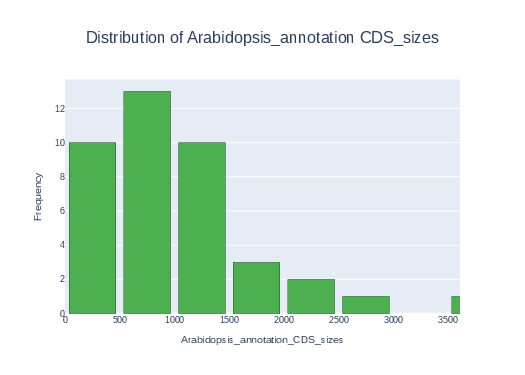

In [9]:
WImage(filename='stats/out_stats/Arabidopsis_annotation_CDS_sizes.pdf')

### Motif finding

In [27]:
genes = list(annotation.all_gene_ids.keys())[:5]

# Search for TATA box motif
tata_motif = "TATAAA"
results = annotation.motifs.find_and_plot(
    query_genes=genes,
    motif=tata_motif,
    motif_length=len(tata_motif),
    glistname="test_response",
    tf_motif_tag="TATA_box",
    custom_path="./motifs/"
)

interest_count, genomic_count, p_value, odds_ratio, percent_interest, percent_genome, p_prop, odds_prop, avg_interest, avg_genome, output_file = results

print(f"TATA box found in {percent_interest:.1f}% of genes vs {percent_genome:.1f}% genome-wide")
print(f"Statistical significance: p-value = {p_value:.2e}")
print(f"Odds ratio: {odds_ratio:.2f}")

TATA box found in 80.0% of genes vs 98.0% genome-wide
Statistical significance: p-value = 5.16e-01
Odds ratio: 0.83


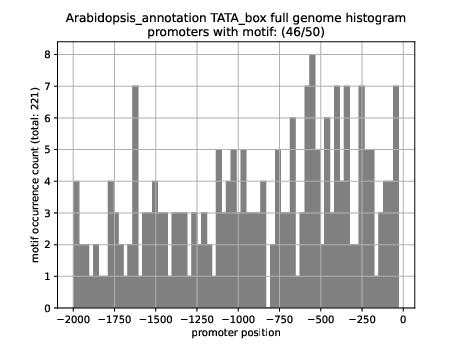

In [11]:
WImage(filename='motifs/motifs/TATA_box_whole_genome.pdf')

### Remove genes with small CDSs, transposable elements, and keep only mRNA. Clean up IDs and standardize naming

In [29]:
annotation.remove_genes_with_small_CDSs(CDS_threshold=300)
annotation.remove_TE_genes()
annotation.filter_by_rna_class(rna_classes=['mRNA'])
annotation.rename_ids(
    features=["gene", "transcript", "CDS", "exon", "UTR"],
    prefix="CLEANED",
    spacer=100
)
annotation.export.gff(tag="at_chr4_subset_clean_annotation.gff3")


Updating features for Arabidopsis_annotation_on_Arabidopsis_genome

Updated features for Arabidopsis_annotation_on_Arabidopsis_genome

Whole update process for Arabidopsis_annotation_on_Arabidopsis_genome annotation object took 0.0 minutes


Updating features for Arabidopsis_annotation_on_Arabidopsis_genome

Updated features for Arabidopsis_annotation_on_Arabidopsis_genome

Whole update process for Arabidopsis_annotation_on_Arabidopsis_genome annotation object took 0.0 minutes


Updating features for Arabidopsis_annotation_on_Arabidopsis_genome

Updated features for Arabidopsis_annotation_on_Arabidopsis_genome

Whole update process for Arabidopsis_annotation_on_Arabidopsis_genome annotation object took 0.0 minutes


Renaming Arabidopsis_annotation_on_Arabidopsis_genome ids with prefix='CLEANED', changing={'UTR', 'exon', 'gene', 'CDS', 'transcript'} features took 0.0 minutes
Exporting Arabidopsis_annotation_on_Arabidopsis_genome gff to /tmp/out_gffs/at_chr4_subset_clean_annotation.gff3

In [13]:
!head -n 20 /tmp/out_gffs/at_chr4_subset_clean_annotation.gff3

##gff-version 3
##gff-3
##sequence-region   Chr4 1180 18584524
#chromosome assembly: TAIR10.1
#genome annotation (gene structure): Araport11
#symbol and full name data generated: 2023-07-01 by TAIR
Chr4	Araport11	gene	351969	355248	.	+	.	ID=CLEANEDChr4g00100;Name=CLEANEDChr4g00100;Note=RNA-binding (RRM/RBD/RNP motifs) family protein;computational_description=RNA-binding (RRM/RBD/RNP motifs) family protein;locus=2134638;locus_type=protein_coding
Chr4	Araport11	mRNA	351969	355248	.	+	.	ID=CLEANEDChr4g00100_t002;Parent=CLEANEDChr4g00100;Note=RNA-binding (RRM/RBD/RNP motifs) family protein;conf_class=2;computational_description=RNA-binding (RRM/RBD/RNP motifs) family protein;conf_rating=****;Dbxref=gene:2134637;uniProt=Q9ASP6;curator_summary=Encodes a heterogeneous nuclear ribonucleoprotein (hnRNP-Q) that is involved in the plant innate immune response and may function as a suppressor of cell-autonomous immunity.
Chr4	Araport11	mRNA	351973	355235	.	+	.	ID=CLEANEDChr4g00100_t001;Parent=CLEA